In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces /content/

In [3]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Dependencies and Imports...

In [6]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.8 MB/s eta 0:00:00


In [53]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import scipy.fftpack as fftpack

import torch.nn.functional as F

import cv2

In [8]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torch.utils.data.dataloader')

Reproducibility...

In [9]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


Configurations...

In [11]:
[x for x in timm.list_models() if 'xception' in x]

['legacy_xception',
 'xception41',
 'xception41p',
 'xception65',
 'xception65p',
 'xception71']

In [125]:
model_name = 'xception65'

image_size = 299
batch_size = 32

learning_rate = 5e-5
weight_decay = 1e-4

maximum_epochs = 20
patience = 5

Dataset Path...

In [126]:
# root = '/content/drive/MyDrive/DL_Project/datasets'

# ffpp_root = os.path.join(root, 'ffpp_cropped_faces')

# celeb_root = os.path.join(root, 'celebv2_cropped_faces')

ffpp_root = '/content/ffpp_cropped_faces'

celeb_root = '/content/celebv2_cropped_faces'

Dataset Staistics...

In [14]:
def count_images(folder):

    real = len(os.listdir(os.path.join(folder,'real')))
    fake = len(os.listdir(os.path.join(folder,'fake')))

    return real, fake

In [15]:
for split in ['train','val','test']:
    real,fake = count_images(os.path.join(ffpp_root, split))

    print('\n', split,':', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


 train : real = 7500 | fake = 6869 | total = 14369

 val : real = 1250 | fake = 1130 | total = 2380

 test : real = 1250 | fake = 1138 | total = 2388


In [16]:
real,fake = count_images(celeb_root)

print('\nceleb-df :', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


celeb-df : real = 2999 | fake = 2991 | total = 5990


DCT Feature Generation...

In [127]:
def compute_dct_map(pil_image, image_size=299):

    image = np.array(pil_image.convert('L'))

    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)

    image = image.astype(np.float32)

    dct_image = fftpack.dct(fftpack.dct(image.T, norm='ortho').T, norm='ortho')

    dct_image = np.log1p(np.abs(dct_image))

    p1 = np.percentile(dct_image, 1)
    p99 = np.percentile(dct_image, 99)

    dct_image = np.clip(dct_image, p1, p99)

    dct_image = (dct_image - dct_image.min()) / (
        dct_image.max()
        - dct_image.min()
        + 1e-8
    )

    return torch.tensor(dct_image, dtype=torch.float32).unsqueeze(0)

Dual Input Dataset...

In [128]:
class DCTDeepfakeDataset(Dataset):

    def __init__(self, root_dir, rgb_transform=None, image_size=299):

        self.rgb_transform = rgb_transform
        self.image_size = image_size

        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in os.listdir(real_dir):

            self.samples.append((os.path.join(real_dir, img), 0))

        for img in os.listdir(fake_dir):

            self.samples.append((os.path.join(fake_dir, img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        rgb_image = image

        if self.rgb_transform:
            rgb_image = self.rgb_transform(rgb_image)

        dct_image = compute_dct_map(image, self.image_size)

        return (rgb_image, dct_image, torch.tensor(label, dtype=torch.float32))

Transforms...

In [145]:
imagenet_mean = [0.485,0.456,0.406]
imagenet_std = [0.229,0.224,0.225]

train_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(imagenet_mean, imagenet_std)])

test_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(imagenet_mean, imagenet_std)])

Dataloaders...

In [146]:
train_ds = DCTDeepfakeDataset(os.path.join(ffpp_root,'train'), rgb_transform=train_transform, image_size=image_size)

val_ds = DCTDeepfakeDataset(os.path.join(ffpp_root,'val'), rgb_transform=test_transform, image_size=image_size)

test_ds = DCTDeepfakeDataset(os.path.join(ffpp_root,'test'), rgb_transform=test_transform, image_size=image_size)

celeb_ds = DCTDeepfakeDataset(celeb_root, rgb_transform=test_transform, image_size=image_size)

In [106]:
rgb, dct_img, label = train_ds[0]

print(rgb.shape)
print(dct_img.shape)
print(label)

torch.Size([3, 299, 299])
torch.Size([1, 299, 299])
tensor(0.)


Dataloaders...

In [147]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

celeb_loader = DataLoader(celeb_ds, batch_size=batch_size, shuffle=False, num_workers=2,pin_memory=True)

print('\nlength of train ffpp :', len(train_ds))
print('\nlength of val ffpp :', len(val_ds))
print('\nlength of test ffpp :', len(test_ds))
print('\nlength of celeb :', len(celeb_ds))


length of train ffpp : 14369

length of val ffpp : 2380

length of test ffpp : 2388

length of celeb : 5990


In [108]:
rgb_batch, dct_batch, labels = next(iter(train_loader))

print('RGB batch shape :', rgb_batch.shape)
print('DCT batch shape :', dct_batch.shape)
print('Labels shape    :', labels.shape)

RGB batch shape : torch.Size([32, 3, 299, 299])
DCT batch shape : torch.Size([32, 1, 299, 299])
Labels shape    : torch.Size([32])


Visualize DCT Features...

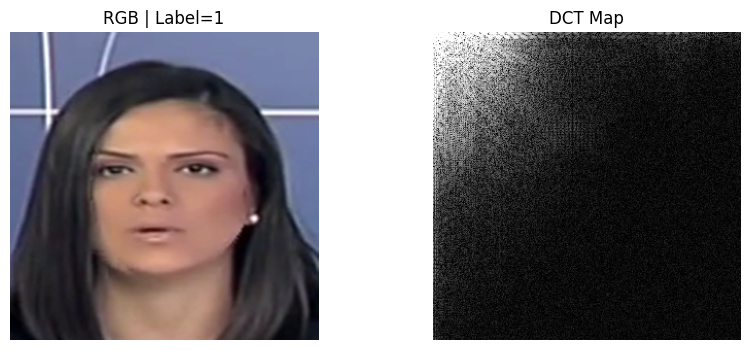

In [148]:
rgb_batch, dct_batch, labels = next(iter(train_loader))

idx = 0

rgb_img = rgb_batch[idx].permute(1,2,0).numpy()

rgb_img = (rgb_img * np.array(imagenet_std) + np.array(imagenet_mean))

rgb_img = np.clip(rgb_img, 0, 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title(f'RGB | Label={int(labels[idx])}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dct_batch[idx].squeeze(0), cmap='gray')
plt.title('DCT Map')
plt.axis('off')

plt.show()

Frequency Branch...

In [149]:
class FrequencyBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(128, 256)

    def forward(self, x):

        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1)

        return x

In [150]:
freq_branch = FrequencyBranch()
dummy_dct = torch.randn(4, 1, 299, 299)

output = freq_branch(dummy_dct)

print(output.shape)

torch.Size([4, 256])


DCTAwareXception...

In [151]:
class DCTAwareXception(nn.Module):

    def __init__(self):

        super().__init__()

        # rgp branch..

        self.rgb_backbone = timm.create_model('xception65', pretrained=True, num_classes=0)

        rgb_feature_dim = self.rgb_backbone.num_features

        # dct branch..

        self.freq_branch = FrequencyBranch()

        # fusion,..

        self.fusion = nn.Sequential(

            nn.Linear(rgb_feature_dim + 256, 512),

            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 1)
        )

    def forward(self, rgb, dct):

        rgb_features = self.rgb_backbone(rgb)
        rgb_features = F.normalize(rgb_features, p=2, dim=1)
        dct_features = self.freq_branch(dct)

        fused = torch.cat([rgb_features, dct_features], dim=1)
        logits = self.fusion(fused)

        return logits.squeeze(1)

In [152]:
model = DCTAwareXception()

model = model.to(device)

rgb = torch.randn(2,3, 299, 299).to(device)

dct = torch.randn(2,1,299, 299).to(device)

with torch.no_grad():
    output = model(rgb, dct)

print(output.shape)

torch.Size([2])


In [114]:
total_parameters = sum(p.numel() for p in model.parameters())

print(f'\nparameters: {total_parameters:,}')


parameters: 39,175,153


In [115]:
print(model.rgb_backbone.num_features)

2048


In [137]:
rgb = torch.randn(2,3,299,299).to(device)

with torch.no_grad():
    feat = model.rgb_backbone(rgb)

print(feat.shape)

torch.Size([2, 2048])


In [153]:
rgb_batch, dct_batch, labels = next(iter(train_loader))

rgb_batch = rgb_batch.to(device)
dct_batch = dct_batch.to(device)

with torch.no_grad():
    outputs = model(rgb_batch, dct_batch)

print(outputs.shape)
print(outputs[:5])

torch.Size([32])
tensor([ 0.7258, -0.4944,  0.1593,  0.1200, -0.4437], device='cuda:0')


Loss / Optimizer ...

In [154]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [155]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

AMP...

In [156]:
scaler = torch.amp.GradScaler('cuda')

Evaluation Function...

In [157]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for rgb_images, dct_images, labels in tqdm(loader, leave=False):

        rgb_images = rgb_images.to(device)
        dct_images = dct_images.to(device)

        labels = labels.to(device)
        outputs = model(rgb_images, dct_images)
        labels = labels.float().view_as(outputs)
        loss = criterion(outputs, labels)

        running_loss += (loss.item() * rgb_images.size(0))

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = (running_loss / len(loader.dataset))
    auc = roc_auc_score(all_labels,all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels,all_preds, zero_division=0)

    recall = recall_score(all_labels, all_preds, zero_division=0)

    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,

        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

In [103]:
val_metrics = evaluate(model, val_loader, criterion)
print(val_metrics.keys())

  0%|          | 0/75 [00:00<?, ?it/s]

dict_keys(['loss', 'auc', 'accuracy', 'precision', 'recall', 'f1', 'labels', 'probs', 'preds'])


Training Loop...

In [158]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_auc': [],

    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

best_auc = 0.0
patience_counter = 0

save_dir = '/content/drive/MyDrive/DL_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, 'best_dct_xception.pth')

for epoch in range(maximum_epochs):

    print(f'\nEpoch [{epoch+1}/{maximum_epochs}]')

    # training..

    model.train()

    running_loss = 0.0

    pbar = tqdm(train_loader)

    for rgb_images, dct_images, labels in pbar:

        rgb_images = rgb_images.to(device, non_blocking=True)
        dct_images = dct_images.to(device,non_blocking=True)

        labels = labels.to(device, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):

            outputs = model(rgb_images,dct_images)
            labels = labels.view_as(outputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += (loss.item() * rgb_images.size(0))

        pbar.set_postfix(loss=f'{loss.item():.4f}')

    train_loss = (running_loss / len(train_loader.dataset))

    # validation...

    val_metrics = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_auc = val_metrics['auc']

    val_acc = val_metrics['accuracy']
    val_precision = val_metrics['precision']
    val_recall = val_metrics['recall']
    val_f1 = val_metrics['f1']

    scheduler.step(val_auc)

    # history..

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    history['val_auc'].append(val_auc)

    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    # logging..

    print(f'\nTrain Loss : {train_loss:.4f}')
    print(f'\nVal Loss   : {val_loss:.4f}')
    print(f'Val AUC    : {val_auc:.4f}')

    print(f'\nVal Accuracy  : {val_acc:.4f}')
    print(f'Val Precision : {val_precision:.4f}')
    print(f'Val Recall    : {val_recall:.4f}')
    print(f'Val F1        : {val_f1:.4f}')

    # saving best model...

    if val_auc > best_auc:
        best_auc = val_auc

        patience_counter = 0

        torch.save({

            'epoch': epoch + 1,

            'model_state_dict':
                model.state_dict(),

            'optimizer_state_dict':
                optimizer.state_dict(),

            'best_auc':
                best_auc

        }, best_model_path)

        print(
            f'\nBest model saved '
            f'(AUC={best_auc:.4f})'
        )

    else:
        patience_counter += 1

        print(
            f'\nNo improvement '
            f'({patience_counter}/{patience})'
        )

    # early stopping,..

    if patience_counter >= patience:
        print('\nEarly stopping triggered...')

        break

history_df = pd.DataFrame(history)

results_dir = ('/content/drive/MyDrive/DL_Project/results/dct_xception')
os.makedirs(results_dir, exist_ok=True)
history_df.to_csv(os.path.join(results_dir, 'dct_xception_training_history.csv'), index=False)
print('training history saved...')


Epoch [1/20]


  0%|          | 0/449 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


Train Loss : 0.4493

Val Loss   : 0.3702
Val AUC    : 0.9207

Val Accuracy  : 0.8374
Val Precision : 0.8482
Val Recall    : 0.8009
Val F1        : 0.8239

Best model saved (AUC=0.9207)

Epoch [2/20]


  0%|          | 0/449 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]


Train Loss : 0.0131

Val Loss   : 0.4852
Val AUC    : 0.9715

Val Accuracy  : 0.9118
Val Precision : 0.8746
Val Recall    : 0.9504
Val F1        : 0.9109

No improvement (4/5)

Epoch [15/20]


  0%|          | 0/449 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


Train Loss : 0.0090

Val Loss   : 0.6536
Val AUC    : 0.9608

Val Accuracy  : 0.8937
Val Precision : 0.8568
Val Recall    : 0.9319
Val F1        : 0.8928

No improvement (5/5)

Early stopping triggered...
training history saved...


Load Model Checkpoint...

In [160]:
checkpoint_path = ('/content/drive/MyDrive/DL_Project/checkpoints/best_dct_xception.pth')
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print(f'best epoch : {checkpoint['epoch']}')
print(f'best auc   : {checkpoint['best_auc']:.4f}')

best epoch : 10
best auc   : 0.9751


In [161]:
print(len(test_loader.dataset))
print(len(celeb_loader.dataset))

2388
5990


Learning Curves...

In [163]:
history_df = pd.read_csv('/content/drive/MyDrive/DL_Project/results/dct_xception/dct_xception_training_history.csv')

In [164]:
history_df['epoch'] = range(1,len(history_df) + 1)
history_df.head()

,train_loss,val_loss,val_auc,val_acc,val_precision,val_recall,val_f1,epoch
0,0.449267,0.370243,0.920736,0.837395,0.848172,0.800885,0.823851,1
1,0.168171,0.439491,0.943684,0.826050,0.752113,0.945133,0.837647,2
2,0.100957,0.395966,0.953439,0.876891,0.833998,0.924779,0.877046,3
3,0.073365,0.552516,0.951046,0.847479,0.776496,0.953097,0.855781,4
4,0.053945,0.426530,0.958575,0.891176,0.867511,0.909735,0.888121,5


In [165]:
output_dir = '/content/drive/MyDrive/DL_Project/results/dct_xception/'
os.makedirs(output_dir, exist_ok=True)

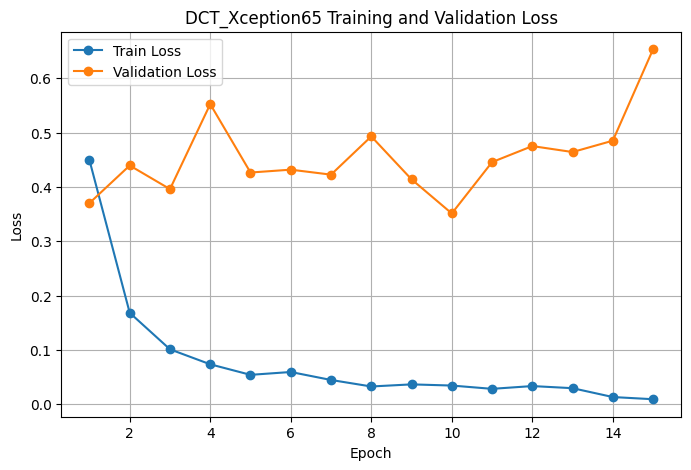

In [170]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')

plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCT_Xception65 Training and Validation Loss')

plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, 'dct_xception65_loss_plot.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

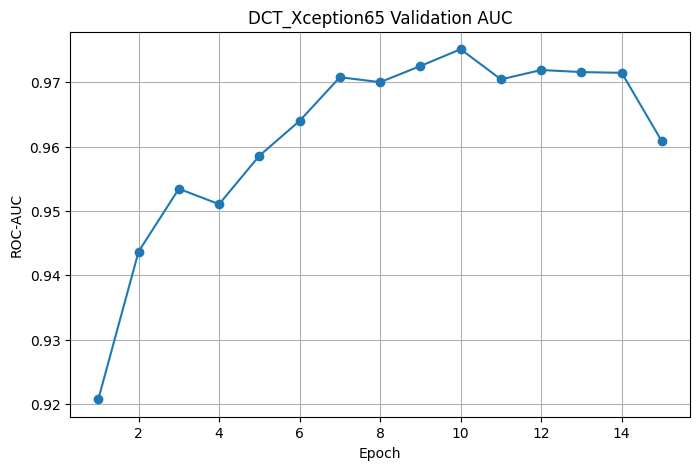

In [171]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['val_auc'], marker='o')

plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('DCT_Xception65 Validation AUC')

plt.grid(True)

save_path = os.path.join(output_dir, 'dct_xception65_auc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

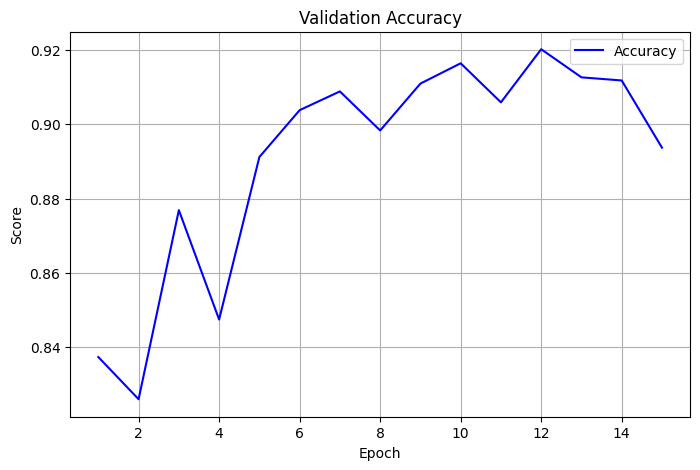

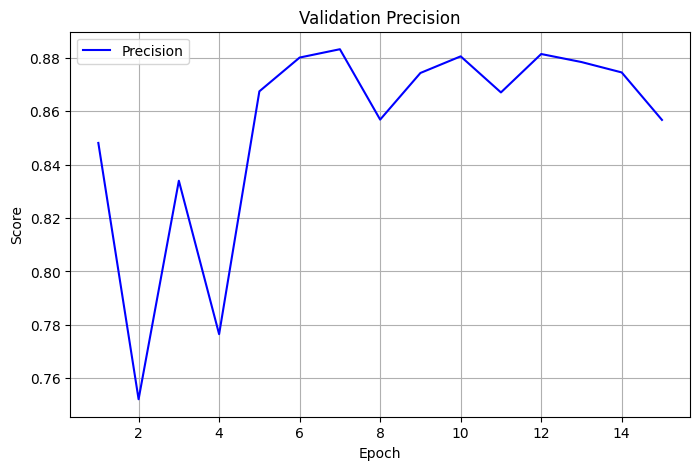

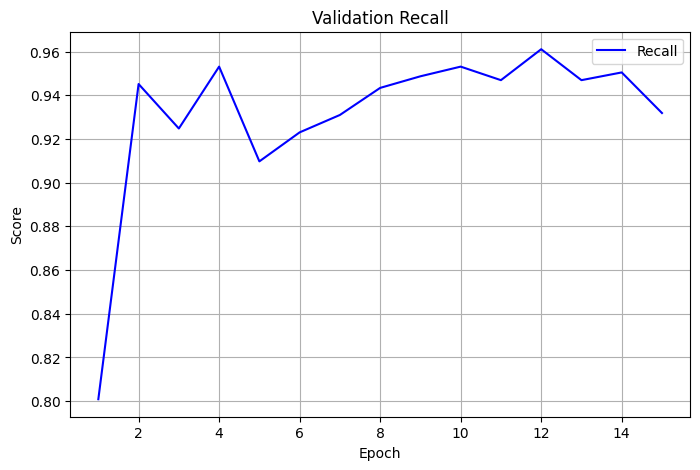

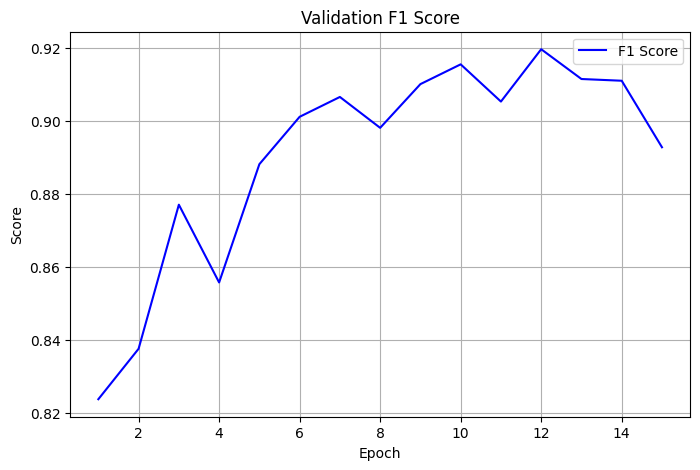

In [172]:
metrics = ['val_acc', 'val_precision', 'val_recall', 'val_f1']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric, name in zip(metrics, display_names):
    plt.figure(figsize=(8,5))

    plt.plot(history_df['epoch'], history_df[metric], label=name, color='blue')

    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title(f'Validation {name}')

    plt.legend()
    plt.grid(True)

    file_name = f'dct_xception65_{metric}.pdf'
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

FF++ Evaluation...

In [169]:
ffpp_metrics = evaluate(model, test_loader, criterion)

print('\nfaceforensics++ test results')

print(f'AUC  : {ffpp_metrics['auc']:.4f}')
print(f'Accuracy  : {ffpp_metrics['accuracy']:.4f}')
print(f'Precision  : {ffpp_metrics['precision']:.4f}')
print(f'Recall  : {ffpp_metrics['recall']:.4f}')
print(f'F1  : {ffpp_metrics['f1']:.4f}')

  0%|          | 0/75 [00:00<?, ?it/s]


faceforensics++ test results
AUC  : 0.9657
Accuracy  : 0.9075
Precision  : 0.8863
Recall  : 0.9244
F1  : 0.9049


FF++ ROC Curve...

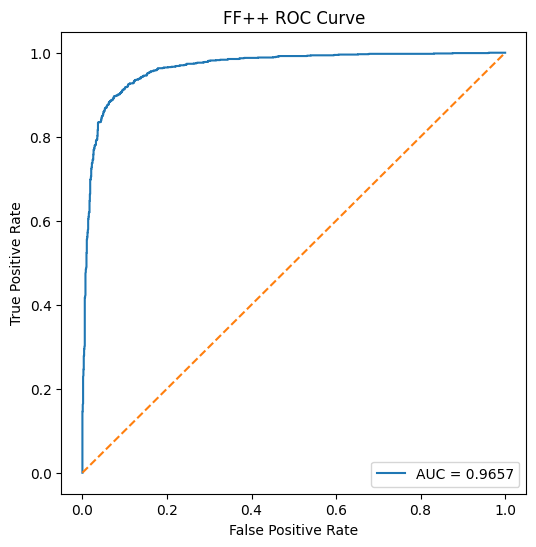

In [173]:
fpr, tpr, _ = roc_curve(ffpp_metrics['labels'], ffpp_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {ffpp_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('FF++ ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'dct_xception65_ffpp_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

FF++ Confusion Matrix...

Exception ignored in: <function tqdm.__del__ at 0x7c2bbd86c180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


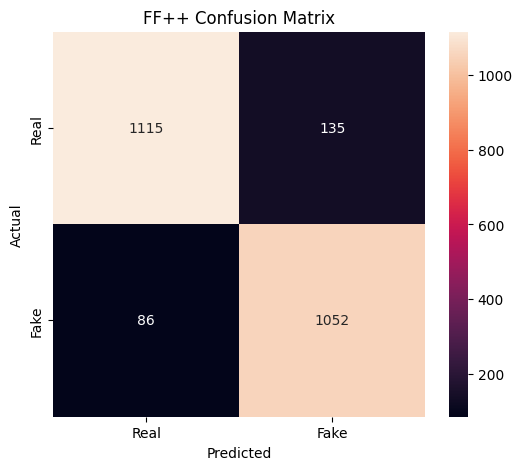

In [174]:
import seaborn as sns

cm = confusion_matrix(ffpp_metrics['labels'], ffpp_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('FF++ Confusion Matrix')

save_path = os.path.join(output_dir, 'dct_xception65_ffpp_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Evaluation...

In [175]:
celeb_metrics = evaluate(model, celeb_loader, criterion)

print('\ncelebv2 evaluation results')

print(f'AUC  : {celeb_metrics['auc']:.4f}')
print(f'Accuracy  : {celeb_metrics['accuracy']:.4f}')
print(f'Precision  : {celeb_metrics['precision']:.4f}')
print(f'Recall  : {celeb_metrics['recall']:.4f}')
print(f'F1  : {celeb_metrics['f1']:.4f}')

  0%|          | 0/188 [00:00<?, ?it/s]


celebv2 evaluation results
AUC  : 0.7885
Accuracy  : 0.7102
Precision  : 0.6630
Recall  : 0.8532
F1  : 0.7462


CelebV2 ROC Curve...

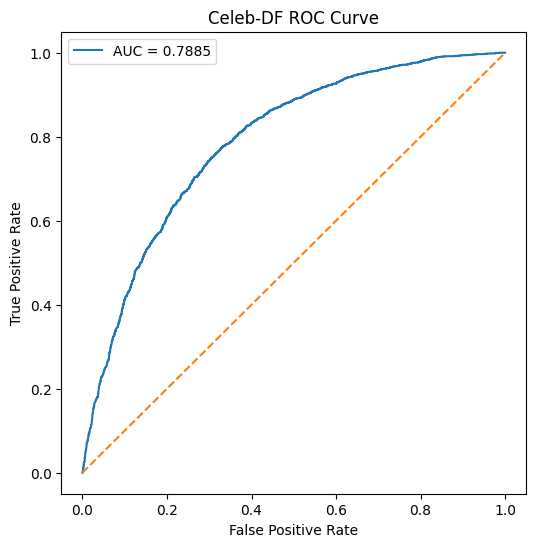

In [176]:
fpr, tpr, _ = roc_curve(celeb_metrics['labels'], celeb_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {celeb_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Celeb-DF ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'dct_xception65_celebv2_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Confusion Matrix...

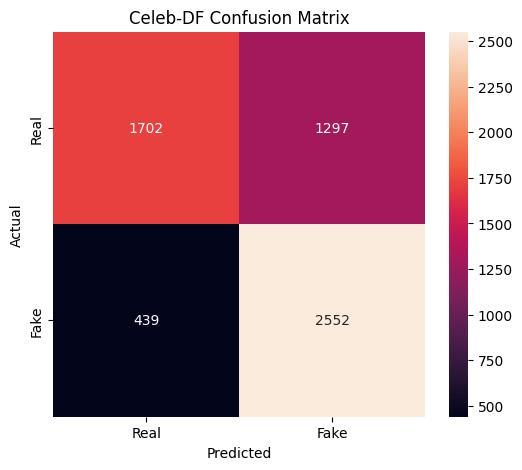

In [177]:
cm = confusion_matrix(celeb_metrics['labels'], celeb_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Celeb-DF Confusion Matrix')

save_path = os.path.join(output_dir, 'dct_xception65_celebv2_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

Generalization Gap...

In [178]:
generalization_gap = (ffpp_metrics['auc'] - celeb_metrics['auc'])

print('\ngeneralization gap')

print(f'FF++ AUC  : {ffpp_metrics['auc']:.4f}')

print(f'CelebDF AUC  : {celeb_metrics['auc']:.4f}')

print(f'Gap  : {generalization_gap:.4f}')


generalization gap
FF++ AUC  : 0.9657
CelebDF AUC  : 0.7885
Gap  : 0.1772


Final Results Table...

In [179]:
results_df = pd.DataFrame([

    {
        'Dataset':'FF++ Test',

        'AUC':ffpp_metrics['auc'],
        'Accuracy':ffpp_metrics['accuracy'],
        'Precision':ffpp_metrics['precision'],
        'Recall':ffpp_metrics['recall'],
        'F1':ffpp_metrics['f1']
    },

    {
        'Dataset':'CelebDF',

        'AUC':celeb_metrics['auc'],
        'Accuracy':celeb_metrics['accuracy'],
        'Precision':celeb_metrics['precision'],
        'Recall':celeb_metrics['recall'],
        'F1':celeb_metrics['f1']
    }
])

results_df

,Dataset,AUC,Accuracy,Precision,Recall,F1
0,FF++ Test,0.965705,0.907454,0.886268,0.924429,0.904946
1,CelebDF,0.788537,0.710184,0.663029,0.853226,0.746199


In [180]:
results_dir = '/content/drive/MyDrive/DL_Project/results/dct_xception/'

os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, 'dct_xception65_results.csv'), index=False)

print('results saved.')

results saved.
